# 08 — Resultados: comparación de experimentos

Consolida los resultados de los cuatro experimentos (más el baseline) sobre el corpus FOMC
2000–2025 (209 docs; split train 2000–2017 / val 2018–2021 / test 2022–2025, las tres clases en
los tres conjuntos). Métrica primaria **F1-macro**; comparación sobre **validación**, test como
generalización out-of-sample.

Los números provienen de los notebooks 04–07 (ya ejecutados). Esta notebook los reúne en una
tabla y figuras comparativas para la presentación.

**Outputs:** `reports/figures/08_comparacion_f1.png`, `reports/figures/08_recall_por_clase_test.png`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='Set2')
BASE_DIR    = Path('..').resolve()
REPORTS_DIR = BASE_DIR / 'reports' / 'figures'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
def save_fig(name): plt.savefig(REPORTS_DIR / name, dpi=120, bbox_inches='tight')

## 1. Tabla comparativa (accuracy y F1-macro, val y test)

F1-macro es la métrica primaria (clases desbalanceadas). La comparación entre modelos se hace
sobre **validación**; el test es generalización out-of-sample.

In [2]:
# Resultados finales de los notebooks 04-07 (F1-macro y accuracy, val y test).
# Tarea X->X (clasificar la decisión de la propia reunión) sobre el dataset ENMASCARADO
# (se removió la mención explícita de la decisión -> anti-leakage; ver notebook 02).
resultados = pd.DataFrame([
    # modelo,                          acc_val, f1_val,  acc_test, f1_test
    ['Baseline (mayoritaria)',          0.750,  0.286,   0.469,   0.213],
    ['Exp 1 — TF-IDF + LogReg',         0.812,  0.519,   0.469,   0.213],
    ['Exp 2 — LM lexicón + LogReg',     0.562,  0.524,   0.281,   0.154],
    ['Exp 3 — Word2Vec + LogReg',       0.781,  0.691,   0.469,   0.396],
    ['Exp 4a — FinBERT frozen + LogReg',0.875,  0.610,   0.594,   0.484],
    ['Exp 4b — FinBERT fine-tuning',    0.938,  0.845,   0.750,   0.741],
], columns=['modelo', 'acc_val', 'f1_val', 'acc_test', 'f1_test'])

display(resultados.set_index('modelo').round(3))
print('Mejor en validación  :', resultados.loc[resultados.f1_val.idxmax(), 'modelo'])
print('Mejor en test (OOS)  :', resultados.loc[resultados.f1_test.idxmax(), 'modelo'])

,acc_val,f1_val,acc_test,f1_test
modelo,,,,
Baseline (mayoritaria),0.750,0.286,0.469,0.213
Exp 1 — TF-IDF + LogReg,0.812,0.519,0.469,0.213
Exp 2 — LM lexicón + LogReg,0.562,0.524,0.281,0.154
Exp 3 — Word2Vec + LogReg,0.781,0.691,0.469,0.396
Exp 4a — FinBERT frozen + LogReg,0.875,0.610,0.594,0.484
Exp 4b — FinBERT fine-tuning,0.938,0.845,0.750,0.741


Mejor en validación  : Exp 4b — FinBERT fine-tuning
Mejor en test (OOS)  : Exp 4b — FinBERT fine-tuning


## 2. F1-macro por modelo (validación vs test)

El orden de los modelos refleja la **escalera de complejidad de la representación**: conteo léxico
(TF-IDF) → tono de dominio (LM) → semántica estática (Word2Vec) → contexto (FinBERT frozen) →
contexto + adaptación (FinBERT fine-tuning).

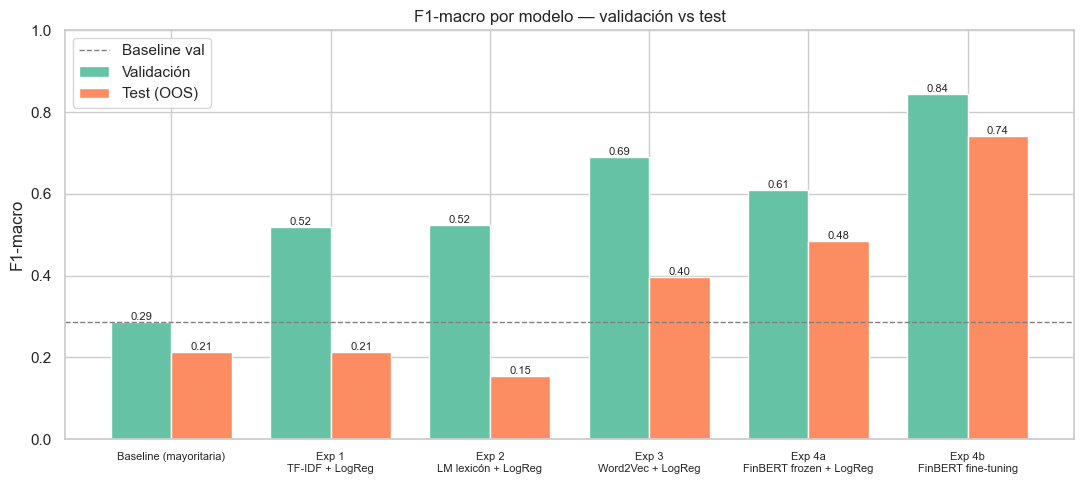

In [3]:
orden = ['Baseline (mayoritaria)', 'Exp 1 — TF-IDF + LogReg', 'Exp 2 — LM lexicón + LogReg',
         'Exp 3 — Word2Vec + LogReg', 'Exp 4a — FinBERT frozen + LogReg', 'Exp 4b — FinBERT fine-tuning']
r = resultados.set_index('modelo').loc[orden]

x = np.arange(len(orden)); width = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, r['f1_val'],  width, label='Validación', color='#66c2a5')
b2 = ax.bar(x + width/2, r['f1_test'], width, label='Test (OOS)', color='#fc8d62')
ax.axhline(r.loc['Baseline (mayoritaria)', 'f1_val'], ls='--', c='gray', lw=1, label='Baseline val')
ax.set_ylabel('F1-macro'); ax.set_title('F1-macro por modelo — validación vs test')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' — ', '\n') for m in orden], fontsize=8)
ax.legend(); ax.set_ylim(0, 1)
for b in list(b1) + list(b2):
    ax.annotate(f'{b.get_height():.2f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout(); save_fig('08_comparacion_f1.png'); plt.show()

## 3. La historia del `cut`: recall por clase en TEST

El test (2022–2025) contiene las tres clases (incluye los recortes de normalización de 2024–25).
Mirar el **recall por clase en test** muestra qué modelo detecta qué — y por qué FinBERT
fine-tuning gana: es el único que reconoce las tres decisiones fuera de muestra.

,hike,cut,hold
modelo,,,
Baseline (mayoritaria),0.00,0.00,1.00
Exp 1 — TF-IDF,0.00,0.00,1.00
Exp 2 — LM lexicón,0.00,0.00,0.60
Exp 3 — Word2Vec,0.91,0.17,0.27
Exp 4a — FinBERT frozen,0.36,0.17,0.93
Exp 4b — FinBERT fine-tuning,0.55,0.83,0.87


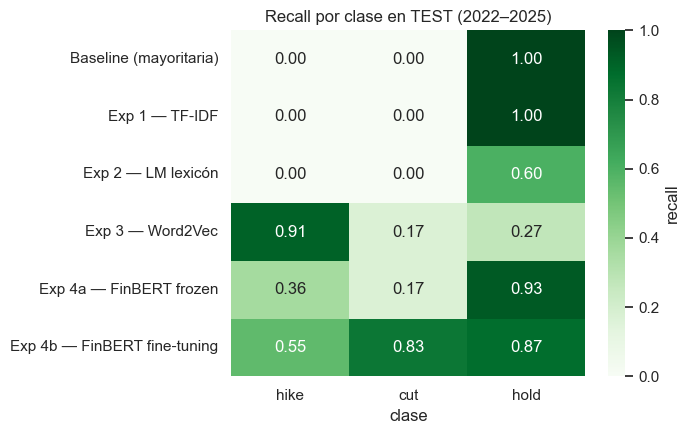

In [4]:
# Recall por clase en TEST (derivado de las matrices de confusión de cada notebook, dataset enmascarado)
recall_test = pd.DataFrame([
    ['Baseline (mayoritaria)',          0.00, 0.00, 1.00],
    ['Exp 1 — TF-IDF',                  0.00, 0.00, 1.00],
    ['Exp 2 — LM lexicón',              0.00, 0.00, 0.60],
    ['Exp 3 — Word2Vec',                0.91, 0.17, 0.27],
    ['Exp 4a — FinBERT frozen',         0.36, 0.17, 0.93],
    ['Exp 4b — FinBERT fine-tuning',    0.55, 0.83, 0.87],
], columns=['modelo', 'hike', 'cut', 'hold']).set_index('modelo')

display(recall_test)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(recall_test, annot=True, fmt='.2f', cmap='Greens', vmin=0, vmax=1,
            cbar_kws={'label': 'recall'}, ax=ax)
ax.set_title('Recall por clase en TEST (2022–2025)')
ax.set_xlabel('clase'); ax.set_ylabel('')
plt.tight_layout(); save_fig('08_recall_por_clase_test.png'); plt.show()

## 4. Conclusiones

Tarea X→X (clasificar la decisión de la propia reunión) sobre el dataset **enmascarado** (la
mención explícita de la decisión fue removida para evitar leakage; ver notebook 02).

- **Escalera de representación:** cada paso resuelve el límite del anterior.
  - **TF-IDF (Exp 1):** conteo léxico exacto. Supera el baseline en val (0.519) pero **colapsa a
    `hold` en test** (0.213) — drift de vocabulario.
  - **Lexicón LM (Exp 2):** tono de dominio (6 features). El tono mide *cómo está* la economía, no
    *qué decide* la Fed → falla en test (0.154).
  - **Word2Vec (Exp 3):** semántica. Primero en generalizar (test 0.396, detecta los hikes), pero el
    mean pooling no capta los recortes (cut recall 0.17).
  - **FinBERT frozen (Exp 4a):** contexto. Mejora test (0.484).
  - **FinBERT fine-tuning (Exp 4b):** contexto + adaptación. **Mejor modelo: F1-macro test 0.741**,
    y **único balanceado en las 3 clases** (cut recall 0.83, hike 0.55, hold 0.87).
- **El enmascarado NO degrada a FinBERT — el 4b mejora (0.648 con leakage → 0.741 enmascarado).**
  Esto prueba que su resultado **no era leakage**: no leía la frase con la decisión, la **infiere**
  de la discusión. Quitar el *tell* explícito (~0.7% del texto) reduce ruido superficial.
- **Fine-tuning > feature extraction:** con lr bajo (1e-5), class weights y early stopping, el full
  fine-tuning sobre 144 docs no sobreajusta — generaliza mejor que el modelo congelado.
- **El `cut` es la clase clave:** solo los modelos contextuales lo detectan en test; 4b lo hace bien
  (recall 0.83). Es lo que separa a FinBERT del resto.
- **Forecasting (X→X+1, notebook 09):** predecir la *próxima* decisión desde el texto **no le gana a
  la persistencia** (test 0.768): la política monetaria es muy inercial. Esto justifica formular el
  TP como X→X, donde el contenido textual sí discrimina.
- **Limitaciones:** corpus chico (209 docs), val/test de 32 → métricas ruidosas; `hike` en test
  sigue siendo difícil; el enmascarado no es 100% leakage-free por el texto garbleado del PDF;
  FinBERT requiere GPU.